In [ ]:

# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

import os
import pandas as pd

# file_path = '/content/drive/Shareddrives/ECS171/instagram_usage_lifestyle.csv'
# df = pd.read_csv(file_path)

import kagglehub
from kagglehub import KaggleDatasetAdapter
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    'rockyt07/social-media-user-analysis',
    'instagram_usage_lifestyle.csv'
)


print(df.head())


/tmp/ipykernel_1551/2702441255.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'social-media-user-analysis' dataset.
   user_id   app_name  age      gender         country urban_rural  \
0        1  Instagram   51      Female           India       Rural   
1        2  Instagram   64      Female  United Kingdom       Urban   
2        3  Instagram   41      Female          Canada       Urban   
3        4  Instagram   27  Non-binary     South Korea       Urban   
4        5  Instagram   55        Male           India       Urban   

   income_level   employment_status education_level relationship_status  ...  \
0          High             Retired      Bachelor’s              Single  ...   
1        Middle  Full-time employed           Other            Divorced  ...   
2        Middle             Student      Bachelor’s   In a relationship  ...   
3        Middle          Unemployed        Master’s   In a relationship  ...   
4  Upper-middle  Full-time employed      Bachelor’s              Single  ...   

  last_login_date

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.optimizers import SGD
from sklearn.model_selection import GridSearchCV

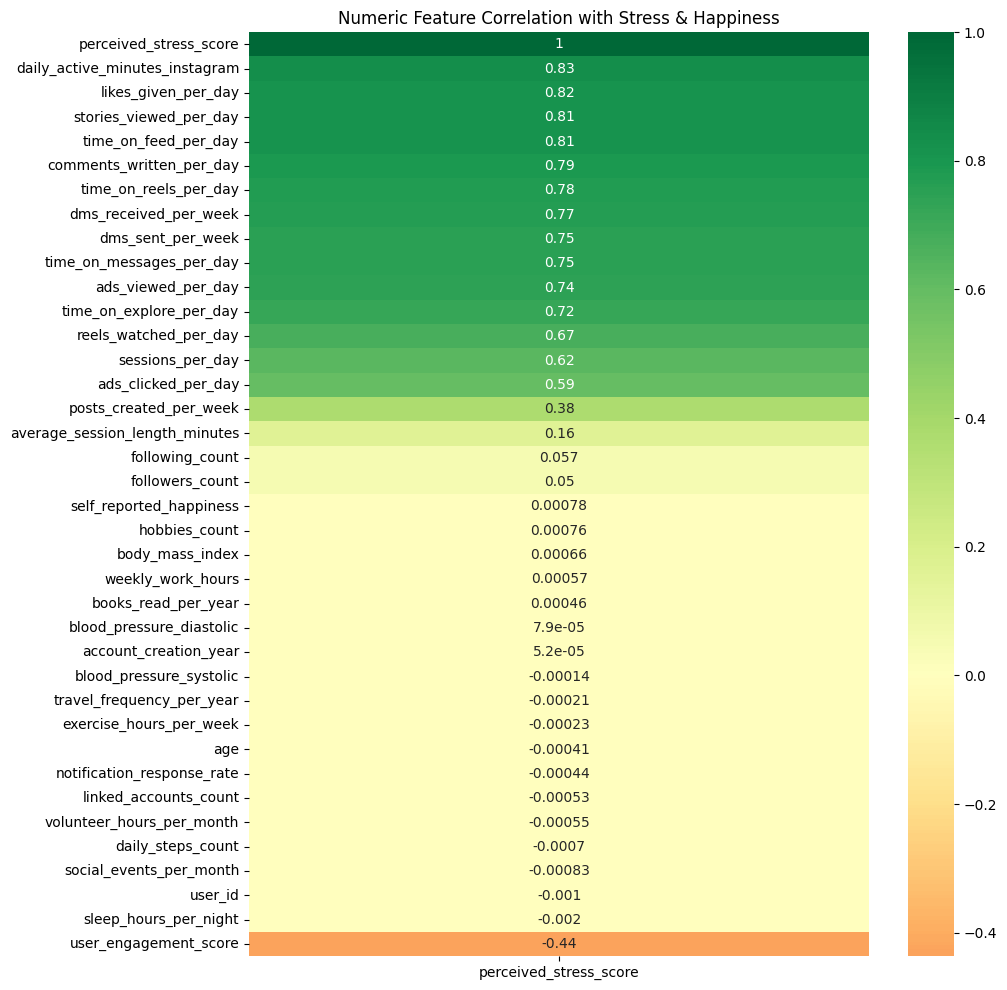

In [ ]:
# redoing EDA, feature correlation map:
numeric_df = df.select_dtypes(include=[np.number])

# numeric_df['active_consumption'] = (numeric_df['dms_sent_per_week']/7 + numeric_df['comments_written_per_day'] ) / numeric_df['daily_active_minutes_instagram']
# numeric_df['passive_consumption'] = (numeric_df['reels_watched_per_day'] + numeric_df['stories_viewed_per_day']) / numeric_df['daily_active_minutes_instagram']


correlations = numeric_df.corr()[['perceived_stress_score']]

correlations = correlations.sort_values(by='perceived_stress_score', ascending=False)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
sns.heatmap(correlations, annot=True, cmap='RdYlGn', center=0)
plt.title("Numeric Feature Correlation with Stress & Happiness")
plt.show()

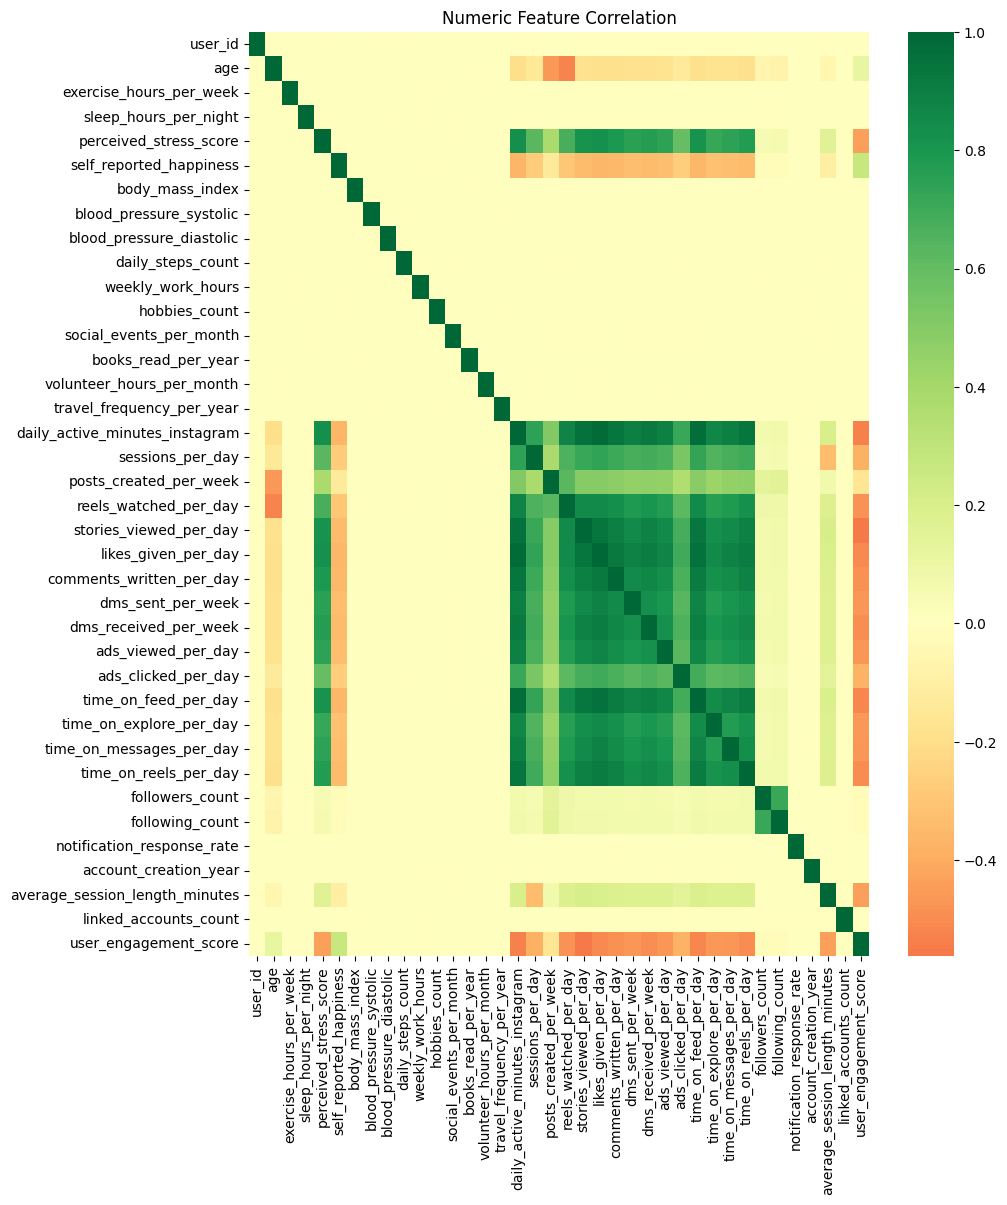

In [ ]:
correlations = numeric_df.corr()
plt.figure(figsize=(10, 12))
sns.heatmap(correlations, cmap='RdYlGn', center=0)
plt.title("Numeric Feature Correlation")
plt.show()

In [ ]:
print(f"shape before dropping duplicates: {df.shape}")

df.isnull().sum()

df = df.drop(columns=['user_id', 'user_engagement_score'])
df = df.drop_duplicates()

print(f"shape after: {df.shape}")

shape before dropping duplicates: (1547896, 58)
shape after: (1547896, 56)


In [ ]:
# numeric RFE:
import pandas as pd
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
df = df[df['country'] == 'United States']

X_numeric = df.select_dtypes(include=[np.number]).drop(columns=['perceived_stress_score'])
X_numeric['active_consumption'] = (X_numeric['dms_sent_per_week']/7 + X_numeric['comments_written_per_day'] ) / X_numeric['daily_active_minutes_instagram']
X_numeric['passive_consumption'] = (X_numeric['reels_watched_per_day'] + X_numeric['stories_viewed_per_day']) / X_numeric['daily_active_minutes_instagram']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_numeric.columns)

y = df[['perceived_stress_score']]

estimator = Ridge()
selector = RFE(estimator, n_features_to_select=10, step=1)

selector = selector.fit(X_scaled_df, y['perceived_stress_score'])

selected_cols = X_numeric.columns[selector.support_].tolist()

print(f"top numeric stress features: {selected_cols}")


top numeric stress features: ['age', 'self_reported_happiness', 'daily_active_minutes_instagram', 'sessions_per_day', 'posts_created_per_week', 'stories_viewed_per_day', 'comments_written_per_day', 'average_session_length_minutes', 'active_consumption', 'passive_consumption']


In [ ]:
# splitting dataset
target = ['perceived_stress_score']
features = ['age', 'daily_active_minutes_instagram', 'self_reported_happiness']

df = df[df['country'] == 'United States']

# df = df.head(50000) # change the number if needed. for poly and linear regression models, it runs fast enough we don't need to cap it

data = df[['age', 'daily_active_minutes_instagram', 'self_reported_happiness', 'perceived_stress_score']]


X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

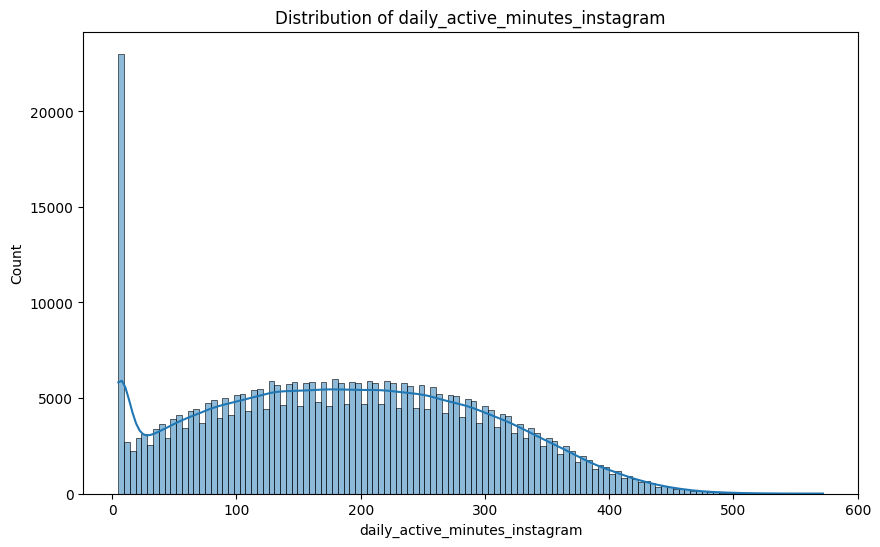

In [ ]:
plt.figure(figsize=(10, 6)) # distribution pre z-score normalization
sns.histplot(df['daily_active_minutes_instagram'], kde= True)
plt.title('Distribution of daily_active_minutes_instagram')
plt.xlabel('daily_active_minutes_instagram')
plt.show()

In [ ]:
# scale data
scaler = StandardScaler()
minmax = MinMaxScaler(feature_range=(1,10))

y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train = minmax.fit_transform(y_train)
y_test = minmax.transform(y_test)

(386829, 3)


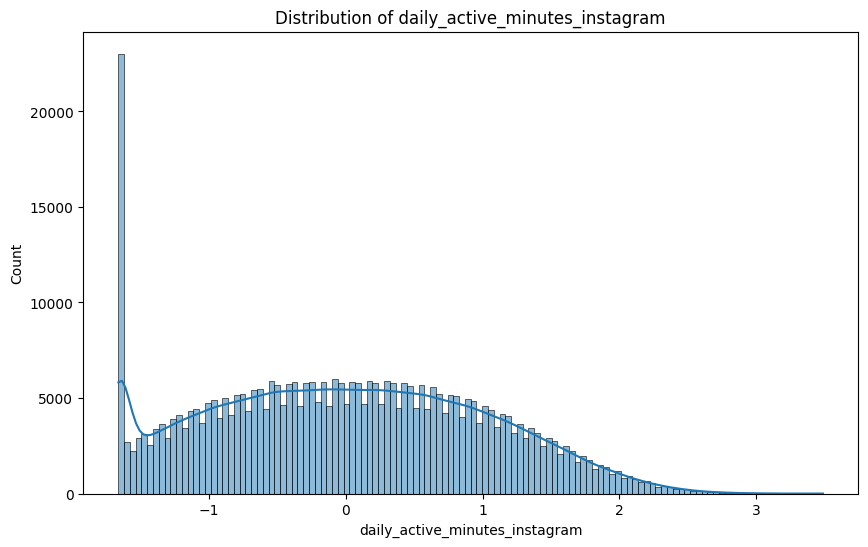

In [ ]:
combined = np.concatenate([X_train, X_test]) # distribution after z-score normalization
# print(type(y_train))
# print(type(y_test))

print(combined.shape)

plt.figure(figsize=(10, 6))
sns.histplot(combined[:,1], kde= True)
plt.title('Distribution of daily_active_minutes_instagram')
plt.xlabel('daily_active_minutes_instagram')
plt.show()

**LINEAR REGRESSION**

**Goal:** Multi-output regression model to predict user’s happiness and stress levels based on their reported social media usage

**Steps:**
1. preprocess the data by standardizing all numerical values to ensure that all features are being scored on the same scale
2. split 80% for training and 20% for testing
3. train a Linear Regression model as a baseline to test for simple linear relationships between usage patterns and lifestyle outcomes

To prevent overfitting, we will use 5-Fold Cross-Validation to ensure consistent performance and Grid Search for hyperparameter tuning. We will evaluate the accuracy of predictions for all models using Mean Square Error (MSE) and R2 scores.

- scikit uses OLS

In [ ]:
# TARGET VALUES: stress

# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

linearModel = LinearRegression()
linearModel.fit(X_train, y_train)

y_pred = linearModel.predict(X_test)

training_mse = mean_squared_error(y_train, linearModel.predict(X_train), multioutput='raw_values')
training_r2 = r2_score(y_train, linearModel.predict(X_train), multioutput='raw_values')
print("Linear model training stats:")
print(f"Stress MSE {training_mse[0]} and Stress R2 = {training_r2[0]}")
print(f"RMSE: {np.sqrt(training_mse[0])}")

mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='raw_values')
print("Linear model test stats:")
print(f"Stress MSE {mse[0]} and Stress R2 = {r2[0]}")
print(f"RMSE: {np.sqrt(mse[0])}")


Linear model training stats:
Stress MSE 1.0813353320886012 and Stress R2 = 0.8475917698198164
RMSE: 1.0398727480267003
Linear model test stats:
Stress MSE 1.0793394827687959 and Stress R2 = 0.8480753610913081
RMSE: 1.0389126444359005


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["variables"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif) # check for multicollinearity

                        variables       VIF
0                             age  4.171506
1  daily_active_minutes_instagram  2.464565
2         self_reported_happiness  3.184152


In [ ]:
# Ridge Regression:
ridgeModel = Ridge()

param_grid = [ {
  'alpha': [0.01, 0.1, 0.9, 1.0, 1.5, 5, 10.0, 100.0],
  'fit_intercept': [True, False]
}]

grid_search = GridSearchCV(ridgeModel, param_grid, cv=5, scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)
bestRidge = grid_search.best_estimator_
print(f"Best Ridge Model: {grid_search.best_params_}")

y_pred = bestRidge.predict(X_test)
training_mse = mean_squared_error(y_train, bestRidge.predict(X_train), multioutput='raw_values')
training_r2 = r2_score(y_train, bestRidge.predict(X_train), multioutput='raw_values')
print("Ridge model training stats:")
print(f"Stress MSE {training_mse[0]} and Stress R2 = {training_r2[0]}")
print(f"RMSE: {np.sqrt(training_mse[0])}")

mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='raw_values')
print("Ridge model test stats:")
print(f"Stress MSE {mse[0]} and Stress R2 = {r2[0]}")
print(f"RMSE: {np.sqrt(mse[0])}")

Best Ridge Model: {'alpha': 0.01, 'fit_intercept': True}
Ridge model training stats:
Stress MSE 1.0813353320886157 and Stress R2 = 0.8475917698198144
RMSE: 1.0398727480267071
Ridge model test stats:
Stress MSE 1.0793394835330476 and Stress R2 = 0.8480753609837343
RMSE: 1.0389126448037138


In [ ]:
# Lasso Regression:
lassoModel = Lasso()

param_grid = [ {
  'alpha': [0.01, 0.1, 0.9, 1.0, 1.5, 5, 10.0, 100.0],
  'fit_intercept': [True, False]
}]

grid_search = GridSearchCV(lassoModel, param_grid, cv=5, scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)
bestLasso = grid_search.best_estimator_
print(f"Best Lasso Model: {grid_search.best_params_}")

y_pred = bestLasso.predict(X_test)
training_mse = mean_squared_error(y_train, bestLasso.predict(X_train), multioutput='raw_values')
training_r2 = r2_score(y_train, bestLasso.predict(X_train), multioutput='raw_values')
print("Lasso model training stats:")
print(f"Stress MSE {training_mse[0]} and Stress R2 = {training_r2[0]}")
print(f"RMSE: {np.sqrt(training_mse[0])}")

mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='raw_values')
print("Lasso model test stats:")
print(f"Stress MSE {mse[0]} and Stress R2 = {r2[0]}")
print(f"RMSE: {np.sqrt(mse[0])}")


Best Lasso Model: {'alpha': 0.01, 'fit_intercept': True}
Lasso model training stats:
Stress MSE 1.081835233214911 and Stress R2 = 0.847521311522871
RMSE: 1.0401130867434132
Lasso model test stats:
Stress MSE 1.0800635129856724 and Stress R2 = 0.8479734487356368
RMSE: 1.039261041791557


   Degree  Stress MSE  Stress R2
0       1    1.081360   0.847584
1       2    1.068141   0.849447
2       3    1.000292   0.859010
3       4    0.998586   0.859251
4       5    0.996905   0.859488


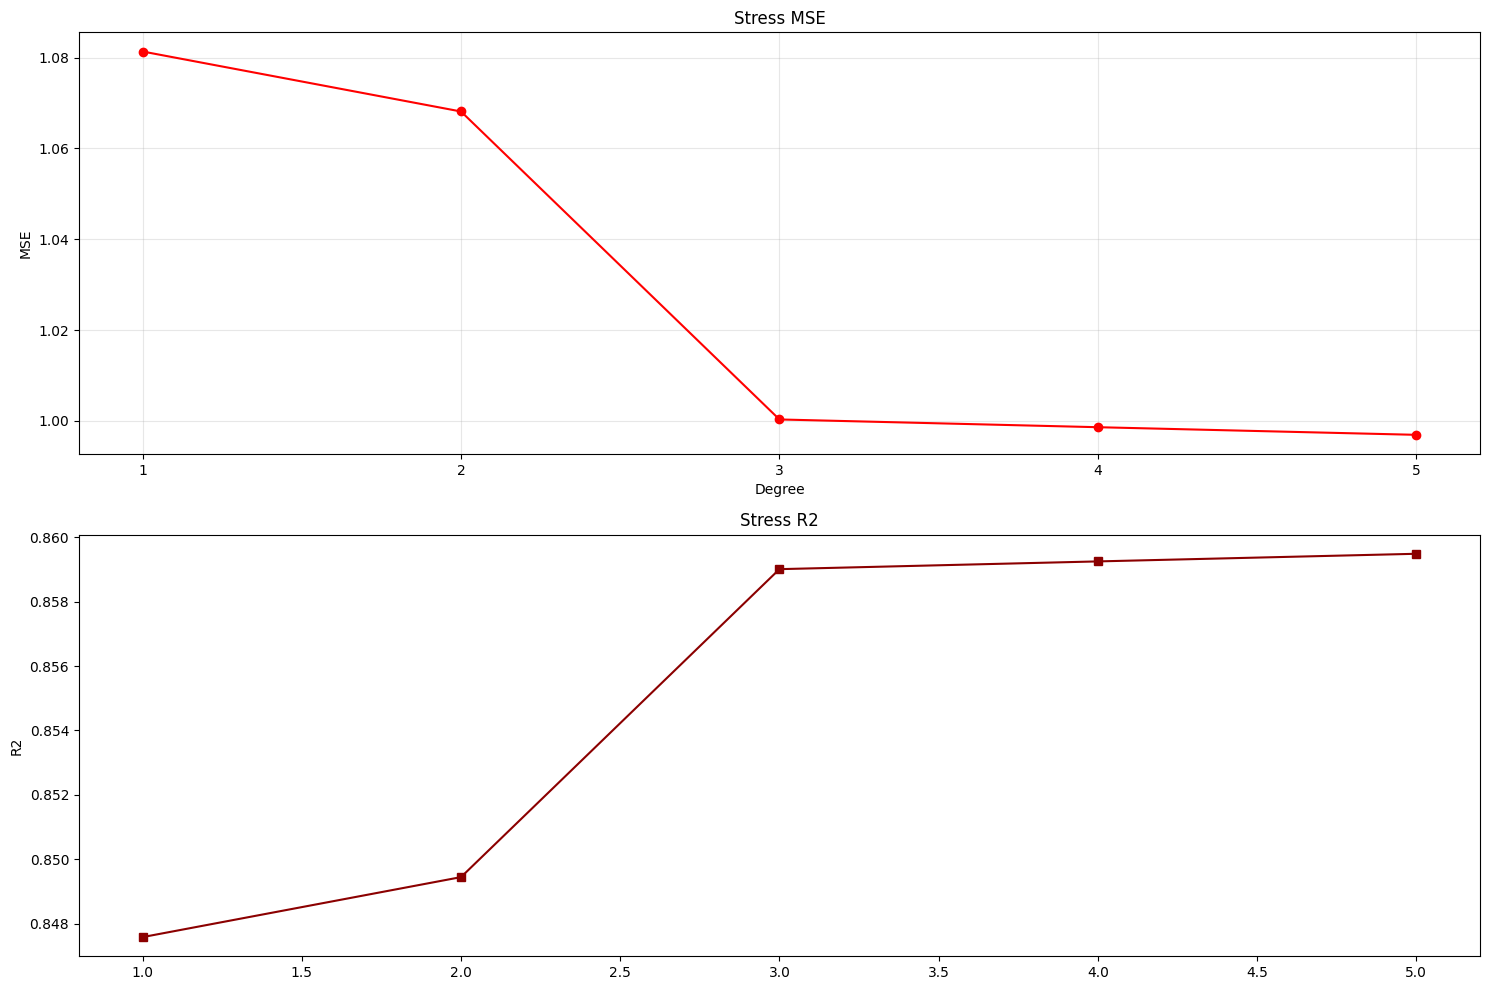

In [ ]:
# Polynomial regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold

degrees = [1, 2, 3, 4, 5]
results = []

kf = KFold(5, shuffle = True, random_state = 67)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)
for degree in degrees:
  poly = PolynomialFeatures(degree = degree)

  foldMetrics = []

  for train_index, test_index in kf.split(X_train):
      X_train_cv, X_test_cv = X_train[train_index], X_train[test_index]
      y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]

      X_train_poly = poly.fit_transform(X_train_cv)
      X_test_poly = poly.transform(X_test_cv)

      scaler_cv = StandardScaler()
      X_train_poly = scaler_cv.fit_transform(X_train_poly)
      X_test_poly = scaler_cv.transform(X_test_poly)

      model = LinearRegression()
      model.fit(X_train_poly, y_train_cv)
      y_pred = model.predict(X_test_poly)

      mse_sep = mean_squared_error(y_test_cv, y_pred, multioutput='raw_values')
      r2_sep = r2_score(y_test_cv, y_pred, multioutput='raw_values')

      foldMetrics.append({
          'stress_mse': mse_sep[0],
          'stress_r2': r2_sep[0],
      })

  avg = pd.DataFrame(foldMetrics).mean()
  results.append({
      'Degree': degree,
      'Stress MSE': avg['stress_mse'],
      'Stress R2': avg['stress_r2'],
})

results_df = pd.DataFrame(results)
print(results_df)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(degrees, results_df['Stress MSE'], marker='o', color='red')
axes[0].set_title('Stress MSE')
axes[0].set_ylabel('MSE')
axes[0].set_xlabel('Degree')
axes[0].set_xticks(degrees)
axes[0].grid(True, alpha=0.3)

axes[1].plot(degrees, results_df['Stress R2'], marker='s', color='darkred')
axes[1].set_title('Stress R2')
axes[1].set_ylabel('R2')
axes[0].set_xlabel('Degree')
axes[0].set_xticks(degrees)
axes[0].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# polynomial scaling
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler2 = StandardScaler()
X_train_poly = scaler2.fit_transform(X_train_poly)
X_test_poly = scaler2.transform(X_test_poly)

In [ ]:
# polynomial regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

training_mse = mean_squared_error(y_train, model.predict(X_train_poly), multioutput='raw_values')
training_r2 = r2_score(y_train, model.predict(X_train_poly), multioutput='raw_values')
print("training:")
print(f"Stress MSE {training_mse[0]} and Stress R2 = {training_r2[0]}")
print(f"RMSE: {np.sqrt(training_mse[0])}")

testing_mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
testing_r2 = r2_score(y_test, y_pred, multioutput='raw_values')
print("Testing")
print(f"Stress MSE {testing_mse[0]} and Stress R2 = {testing_r2[0]}")
print(f"RMSE: {np.sqrt(testing_mse[0])}")

training:
Stress MSE 1.000180519678074 and Stress R2 = 0.8590300914607113
RMSE: 1.0000902557659854
Testing
Stress MSE 0.9963419946187295 and Stress R2 = 0.8597578424781473
RMSE: 0.998169321617695


In [ ]:
import statsmodels.api as sm
sm_model = sm.OLS(y_train, X_train).fit()

print(sm_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.161
Model:                            OLS   Adj. R-squared (uncentered):              0.161
Method:                 Least Squares   F-statistic:                          1.985e+04
Date:                Sun, 15 Mar 2026   Prob (F-statistic):                        0.00
Time:                        04:59:43   Log-Likelihood:                     -9.7168e+05
No. Observations:              309463   AIC:                                  1.943e+06
Df Residuals:                  309460   BIC:                                  1.943e+06
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

77366


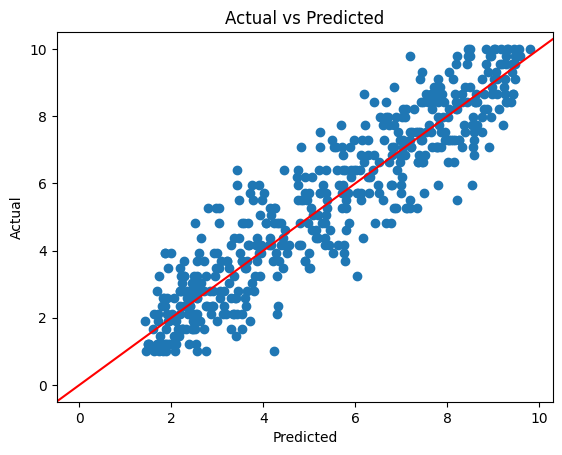

In [ ]:
# print(type(y_pred))
print(len(y_test))

indices = np.random.choice(len(y_test), size=500, replace=False)
y_test_sample = y_test[indices]
y_pred_sample = y_pred[indices]

# plt.scatter(y_test_sample, y_pred_sample)
plt.scatter(y_pred_sample, y_test_sample)
# plt.axhline(y=0, color='r')
plt.axline([0, 0], slope=1, color='r')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Actual vs Predicted')
# plt.plot(y_pred, label='Predicted')
# plt.legend()
plt.show()

In [ ]:
# Polynomial with Lasso
model = Lasso(alpha = 0.01, fit_intercept=True, max_iter = 5000 ) #'alpha': 0.01, 'fit_intercept': True
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

training_mse = mean_squared_error(y_train, model.predict(X_train_poly), multioutput='raw_values')
training_r2 = r2_score(y_train, model.predict(X_train_poly), multioutput='raw_values')
print("Lasso Polynomial Results:")
print("training:")
print(f"Stress MSE {training_mse[0]} and Stress R2 = {training_r2[0]}")
print(f"RMSE: {np.sqrt(training_mse[0])}")

testing_mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
testing_r2 = r2_score(y_test, y_pred, multioutput='raw_values')
print("Testing")
print(f"Stress MSE {testing_mse[0]} and Stress R2 = {testing_r2[0]}")
print(f"RMSE: {np.sqrt(testing_mse[0])}")

Lasso Polynomial Results:
training:
Stress MSE 1.0132053634752396 and Stress R2 = 0.8571943118162368
RMSE: 1.0065810267808746
Testing
Stress MSE 1.0098828581527695 and Stress R2 = 0.8578518705056929
RMSE: 1.0049292801748635


In [ ]:
# Polynomial with Ridge:
model = Ridge(alpha = 1.5, fit_intercept = True)
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

training_mse = mean_squared_error(y_train, model.predict(X_train_poly), multioutput='raw_values')
training_r2 = r2_score(y_train, model.predict(X_train_poly), multioutput='raw_values')
print("Ridge Polynomial Results:")
print("training:")
print(f"Stress MSE {training_mse[0]} and Stress R2 = {training_r2[0]}")
print(f"RMSE: {np.sqrt(training_mse[0])}")

testing_mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
testing_r2 = r2_score(y_test, y_pred, multioutput='raw_values')
print("Testing")
print(f"Stress MSE {testing_mse[0]} and Stress R2 = {testing_r2[0]}")
print(f"RMSE: {np.sqrt(testing_mse[0])}")

Ridge Polynomial Results:
training:
Stress MSE 1.0001805245377102 and Stress R2 = 0.8590300907757724
RMSE: 1.0000902581955842
Testing
Stress MSE 0.9963424834937815 and Stress R2 = 0.8597577736655384
RMSE: 0.9981695665034982


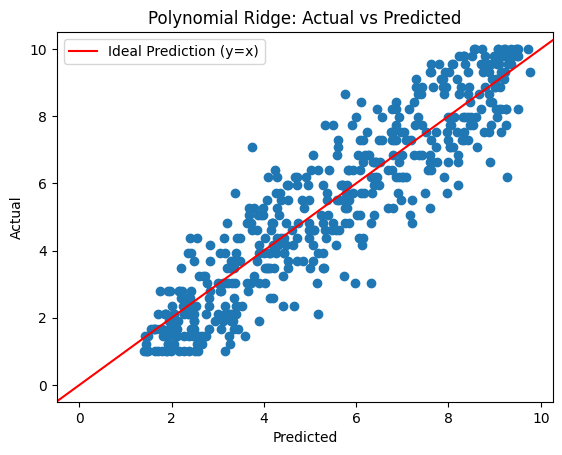

In [ ]:
indices = np.random.choice(len(y_test), size=500, replace=False)
y_test_sample = y_test[indices]
y_pred_sample = y_pred[indices]

plt.scatter(y_pred_sample, y_test_sample)
plt.axline([0, 0], slope=1, color='r', label='Ideal Prediction (y=x)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Polynomial Ridge: Actual vs Predicted')
plt.legend()
plt.show()

In [ ]:
input = [20, 30, 5]
input = scaler.transform([input])
input = poly.transform(input)
input = scaler2.transform(input)
print(model.predict(input))


input = [21, 720, 3]
input = scaler.transform([input])
input = poly.transform(input)
input = scaler2.transform(input)
print(model.predict(input))


input = [34, 200, 5]
input = scaler.transform([input])
input = poly.transform(input)
input = scaler2.transform(input)
print(model.predict(input))

input = [55, 120, 8]
input = scaler.transform([input])
input = poly.transform(input)
input = scaler2.transform(input)
print(model.predict(input))

[1.51603409]
[-1.9241412]
[5.48233278]
[5.33304267]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rfmodel = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=20)

In [ ]:
X_trainrf, X_testrf, y_trainrf, y_testrf = train_test_split(X, y, test_size=0.2, random_state=67)

In [ ]:
rfmodel.fit(X_trainrf, y_trainrf)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=20, random_state=42)

In [ ]:
y_pred_rf = rfmodel.predict(X_testrf)

In [ ]:
training_mse_rf = mean_squared_error(y_trainrf, rfmodel.predict(X_trainrf), multioutput='raw_values')
training_r2_rf = r2_score(y_trainrf, rfmodel.predict(X_trainrf), multioutput='raw_values')
print("Baseline Random Forest training stats:")
print(f"Stress MSE {training_mse_rf[0]} and Stress R2 = {training_r2_rf[0]}")
print(f"RMSE: {np.sqrt(training_mse_rf[0])}")

Baseline Random Forest training stats:
Stress MSE 11.492120195635948 and Stress R2 = 0.9180001189889933
RMSE: 3.3900029787060584


In [ ]:
# Rescale Random Forest predictions from 1-40 range to 1-10 range
y_trainrf_pred_scaled = minmax.transform(rfmodel.predict(X_trainrf).reshape(-1, 1))

# Scale y_testrf to the 1-10 range as well for correct metric calculation
y_trainrf_scaled = minmax.transform(y_trainrf.values.reshape(-1, 1))

# Recalculate metrics with scaled predictions and scaled actual values
training_mse_rf_scaled = mean_squared_error(y_trainrf_scaled, y_trainrf_pred_scaled, multioutput='raw_values')
training_r2_rf_scaled = r2_score(y_trainrf_scaled, y_trainrf_pred_scaled, multioutput='raw_values')

print("Baseline Random Forest training stats (SCALED):")
print(f"Stress MSE: {training_mse_rf_scaled[0]:.4f} and Stress R²: {training_r2_rf_scaled[0]:.4f}")
print(f"RMSE: {np.sqrt(training_mse_rf_scaled[0]):.4f}")


Baseline Random Forest training stats (SCALED):
Stress MSE: 0.5818 and Stress R²: 0.9180
RMSE: 0.7628


In [ ]:
mse_rf = mean_squared_error(y_testrf, y_pred_rf, multioutput='raw_values')
r2_rf = r2_score(y_testrf, y_pred_rf, multioutput='raw_values')
print("Baseline Random Forest test stats:")
print(f"Stress MSE {mse_rf[0]} and Stress R2 = {r2_rf[0]}")
print(f"RMSE: {np.sqrt(mse_rf[0])}")

Baseline Random Forest test stats:
Stress MSE 24.941062382876286 and Stress R2 = 0.8222743408597271
RMSE: 4.994102760544309


In [ ]:
# Rescale Random Forest predictions from 1-40 range to 1-10 range
y_pred_rf_scaled = minmax.transform(y_pred_rf.reshape(-1, 1))  # CHANGED: use y_pred_rf, not y_pred_rf_best

# Scale y_testrf to the 1-10 range as well for correct metric calculation
y_testrf_scaled = minmax.transform(y_testrf.values.reshape(-1, 1))

# Recalculate metrics with scaled predictions and scaled actual values
mse_rf_scaled = mean_squared_error(y_testrf_scaled, y_pred_rf_scaled, multioutput='raw_values')  # CHANGED: use y_pred_rf_scaled
r2_rf_scaled = r2_score(y_testrf_scaled, y_pred_rf_scaled, multioutput='raw_values')  # CHANGED: use y_pred_rf_scaled

print("\nBaseline Random Forest test stats (SCALED):")
print(f"Stress MSE {mse_rf_scaled[0]} and Stress R2 = {r2_rf_scaled[0]}")
print(f"RMSE: {np.sqrt(mse_rf_scaled[0])}")


Baseline Random Forest test stats (SCALED):
Stress MSE 1.262641283133112 and Stress R2 = 0.8222743408597271
RMSE: 1.1236731211224695


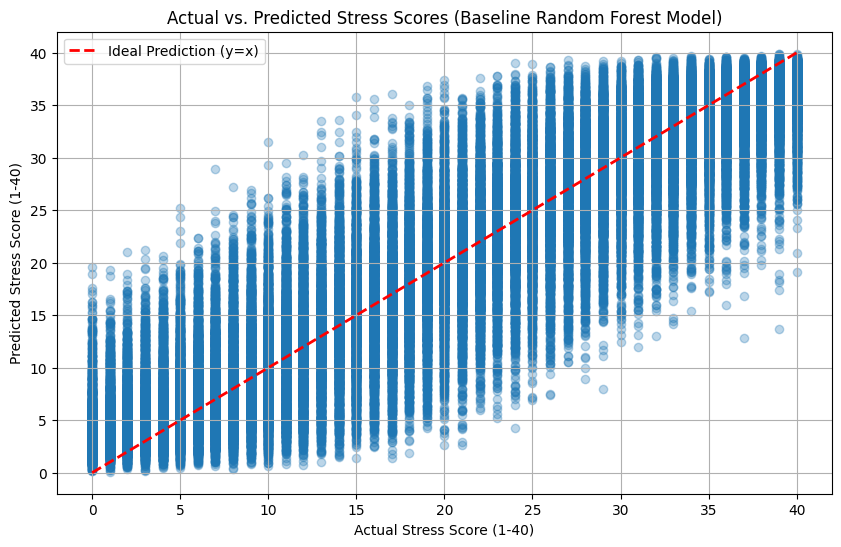

In [ ]:
# Plot baseline model
plt.figure(figsize=(10, 6))
plt.scatter(y_testrf, y_pred_rf, alpha=0.3)  # CHANGED: use y_pred_rf (baseline), not y_pred_rf_best
plt.plot([y_testrf.min(), y_testrf.max()], [y_testrf.min(), y_testrf.max()], 'r--', lw=2, label='Ideal Prediction (y=x)')
plt.xlabel('Actual Stress Score (1-40)')
plt.ylabel('Predicted Stress Score (1-40)')
plt.title('Actual vs. Predicted Stress Scores (Baseline Random Forest Model)')  # CHANGED: Baseline instead of Best
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rfmodel.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
                          Feature  Importance
1  daily_active_minutes_instagram    0.803062
2         self_reported_happiness    0.120121
0                             age    0.076817


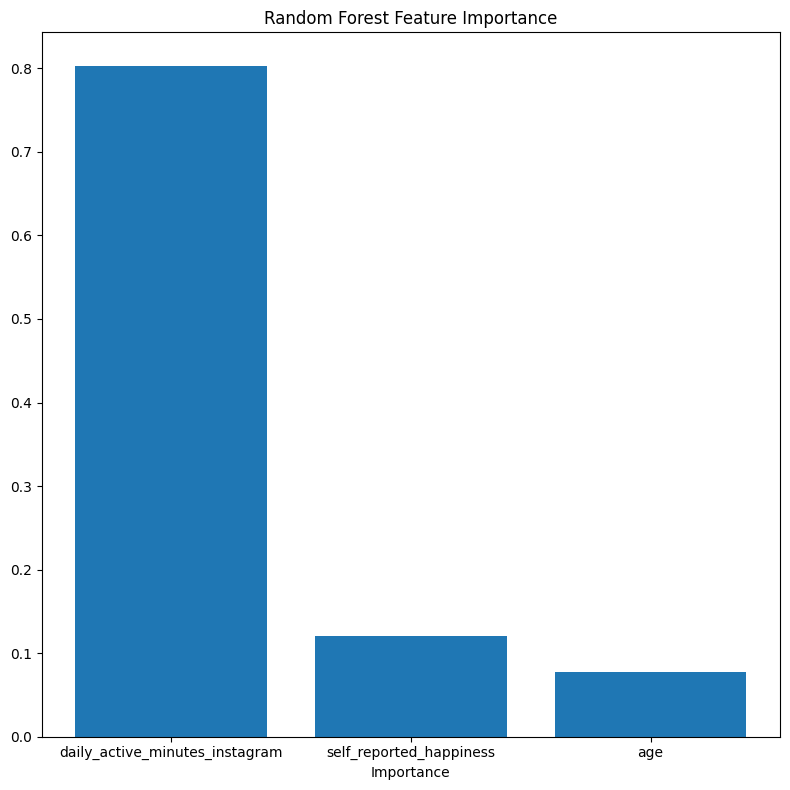

In [ ]:
plt.figure(figsize=(8, 8))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [8, 12, 15],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [4, 8]
}

rf_base = RandomForestRegressor(n_estimators=100, random_state=67)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=2
)

grid_search.fit(X_trainrf, y_trainrf)

best_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV MSE: {-grid_search.best_score_}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best Parameters: {'max_depth': 12, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best CV MSE: 20.0146358238531


In [ ]:
y_pred_rf_best = best_rf.predict(X_testrf)

In [ ]:
training_mse_rf_best = mean_squared_error(y_trainrf, best_rf.predict(X_trainrf), multioutput='raw_values')
training_r2_rf_best = r2_score(y_trainrf, best_rf.predict(X_trainrf), multioutput='raw_values')
print("Best Random Forest training stats:")
print(f"Stress MSE {training_mse_rf_best[0]} and Stress R2 = {training_r2_rf_best[0]}")
print(f"RMSE: {np.sqrt(training_mse_rf_best[0])}")

Best Random Forest training stats:
Stress MSE 18.58463291647833 and Stress R2 = 0.8673928168308607
RMSE: 4.310989783852234


In [ ]:
# Rescale BEST model predictions from 1-40 range to 1-10 range
y_trainrf_pred_best_scaled = minmax.transform(best_rf.predict(X_trainrf).reshape(-1, 1))  # CHANGED: use best_rf, not rfmodel

# Scale y_trainrf to the 1-10 range as well for correct metric calculation
y_trainrf_scaled = minmax.transform(y_trainrf.values.reshape(-1, 1))

# Recalculate metrics with scaled predictions and scaled actual values
training_mse_rf_best_scaled = mean_squared_error(y_trainrf_scaled, y_trainrf_pred_best_scaled, multioutput='raw_values')  # CHANGED: variable name
training_r2_rf_best_scaled = r2_score(y_trainrf_scaled, y_trainrf_pred_best_scaled, multioutput='raw_values')  # CHANGED: variable name

print("\nBest Random Forest training stats (SCALED):")
print(f"Stress MSE: {training_mse_rf_best_scaled[0]:.4f} and Stress R²: {training_r2_rf_best_scaled[0]:.4f}")
print(f"RMSE: {np.sqrt(training_mse_rf_best_scaled[0]):.4f}")


Best Random Forest training stats (SCALED):
Stress MSE: 0.9408 and Stress R²: 0.8674
RMSE: 0.9700


In [ ]:
mse_rf_best = mean_squared_error(y_testrf, y_pred_rf_best, multioutput='raw_values')
r2_rf_best = r2_score(y_testrf, y_pred_rf_best, multioutput='raw_values')
print("Best Random Forest test stats:")
print(f"Stress MSE {mse_rf_best[0]} and Stress R2 = {r2_rf_best[0]}")
print(f"RMSE: {np.sqrt(mse_rf_best[0])}")

Best Random Forest test stats:
Stress MSE 19.840485150064193 and Stress R2 = 0.8586201643367484
RMSE: 4.4542659496334736


In [ ]:
# Rescale BEST model predictions from 1-40 range to 1-10 range
y_pred_rf_best_scaled = minmax.transform(y_pred_rf_best.reshape(-1, 1))

# Scale y_testrf to the 1-10 range as well for correct metric calculation
y_testrf_scaled = minmax.transform(y_testrf.values.reshape(-1, 1))

# Recalculate metrics with scaled predictions and scaled actual values
mse_rf_best_scaled = mean_squared_error(y_testrf_scaled, y_pred_rf_best_scaled, multioutput='raw_values')
r2_rf_best_scaled = r2_score(y_testrf_scaled, y_pred_rf_best_scaled, multioutput='raw_values')

print("\nBest Random Forest test stats (SCALED):")
print(f"Stress MSE: {mse_rf_best_scaled[0]:.4f} and Stress R²: {r2_rf_best_scaled[0]:.4f}")
print(f"RMSE: {np.sqrt(mse_rf_best_scaled[0]):.4f}")


Best Random Forest test stats (SCALED):
Stress MSE: 1.0044 and Stress R²: 0.8586
RMSE: 1.0022


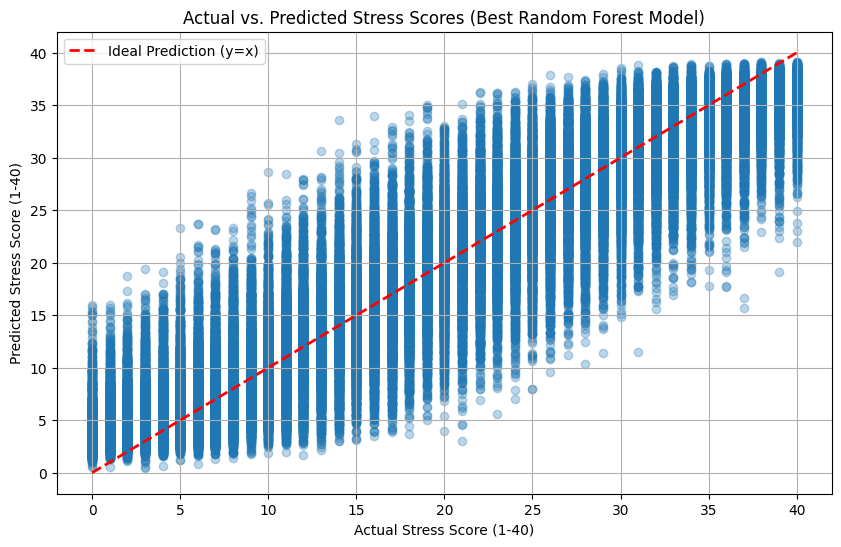

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_testrf, y_pred_rf_best, alpha=0.3)
plt.plot([y_testrf.min(), y_testrf.max()], [y_testrf.min(), y_testrf.max()], 'r--', lw=2, label='Ideal Prediction (y=x)')
plt.xlabel('Actual Stress Score (1-40)')
plt.ylabel('Predicted Stress Score (1-40)')
plt.title('Actual vs. Predicted Stress Scores (Best Random Forest Model)')
plt.legend()
plt.grid(True)
plt.show()

# If you wish to plot the scaled values:
# plt.figure(figsize=(10, 6))
# plt.scatter(minmax.transform(y_testrf), y_pred_rf_best_scaled, alpha=0.3)
# plt.plot([minmax.transform(y_testrf).min(), minmax.transform(y_testrf).max()], [minmax.transform(y_testrf).min(), minmax.transform(y_testrf).max()], 'r--', lw=2, label='Ideal Prediction (y=x)')
# plt.xlabel('Actual Stress Score (1-10)')
# plt.ylabel('Predicted Stress Score (1-10)')
# plt.title('Actual vs. Predicted Stress Scores (Best Random Forest Model, Scaled)')
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
feature_importance_best = pd.DataFrame({
    'Feature': features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nBest Model Feature Importance:")
print(feature_importance_best)


Best Model Feature Importance:
                          Feature  Importance
1  daily_active_minutes_instagram    0.825938
2         self_reported_happiness    0.128298
0                             age    0.045764


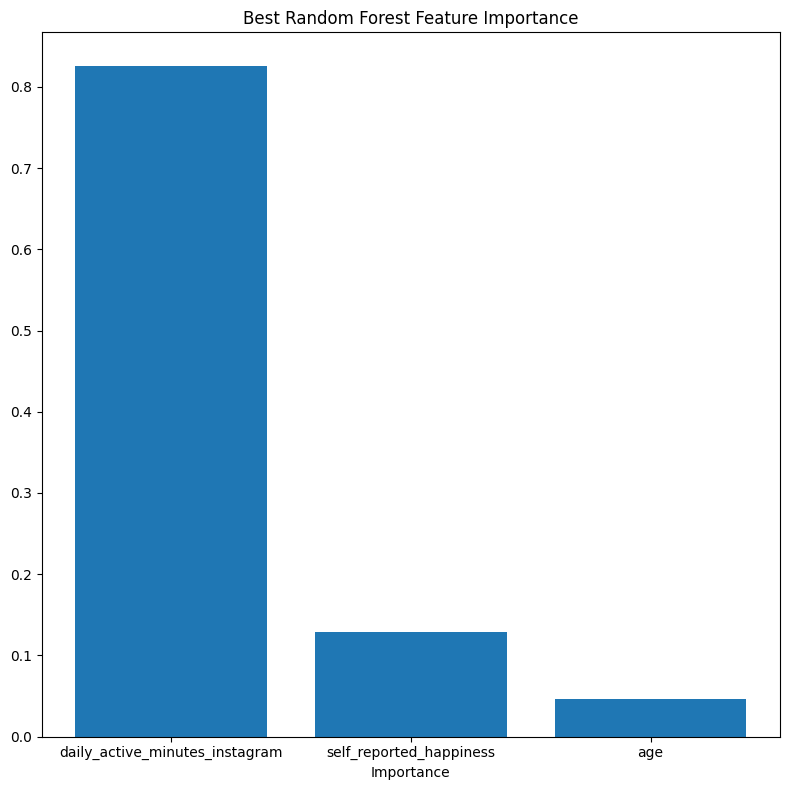

In [ ]:
plt.figure(figsize=(8, 8))
plt.bar(feature_importance_best['Feature'], feature_importance_best['Importance'])
plt.xlabel('Importance')
plt.title('Best Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

rf_summary = pd.DataFrame({
    'Model': ['Baseline RF', 'Baseline RF', 'Best RF', 'Best RF'],
    'Dataset': ['Training', 'Test', 'Training', 'Test'],
    'MSE (Scaled)': [
        training_mse_rf_scaled[0],
        mse_rf_scaled[0],
        training_mse_rf_best_scaled[0],
        mse_rf_best_scaled[0]
    ],
    'RMSE (Scaled)': [
        np.sqrt(training_mse_rf_scaled[0]),
        np.sqrt(mse_rf_scaled[0]),
        np.sqrt(training_mse_rf_best_scaled[0]),
        np.sqrt(mse_rf_best_scaled[0])
    ],
    'R2 (Scaled)': [
        training_r2_rf_scaled[0],
        r2_rf_scaled[0],
        training_r2_rf_best_scaled[0],
        r2_rf_best_scaled[0]
    ]
})

print("\n" + "=" * 90)
print("RANDOM FOREST SUMMARY TABLE (Scaled to 1-10 Range)")
print("=" * 90)
print(rf_summary.to_string(index=False))
print("=" * 90)


RANDOM FOREST SUMMARY TABLE (Scaled to 1-10 Range)
      Model  Dataset  MSE (Scaled)  RMSE (Scaled)  R2 (Scaled)
Baseline RF Training      0.581789       0.762751     0.918000
Baseline RF     Test      1.262641       1.123673     0.822274
    Best RF Training      0.940847       0.969973     0.867393
    Best RF     Test      1.004425       1.002210     0.858620


**XGBOOST**

In [ ]:
!pip install pandas numpy xgboost scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression

df_usage = pd.read_csv('instagram_usage_lifestyle.csv')

df = df_usage[df_usage['country'].isin(['United States'])].copy()

features = ['age','daily_active_minutes_instagram','self_reported_happiness']
target = ['perceived_stress_score']

df = df[features + target]

X = df[features]
y = df[target].values.reshape(-1)

mi_scores = mutual_info_regression(X, y.squeeze(), random_state=42)
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Information Gain': mi_scores
}).sort_values('Information Gain', ascending=True)
print("Information Gain per Feature:")
print(mi_df.to_string(index=False))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
if len(X_train) >= 30000:
    X_train = X_train.iloc[:30000]
    y_train = y_train[:30000]

minmax = MinMaxScaler(feature_range=(1, 10))

y_train = minmax.fit_transform(y_train.reshape(-1, 1))
y_test = minmax.transform(y_test.reshape(-1, 1))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

xgb_estimator = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_grid = {
    'booster': ['dart'],
    'rate_drop': [0.1, 0.2],
    'n_estimators': [100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [1.0],
    'min_child_weight': [1, 3]
}

grid_search = GridSearchCV(
    estimator=xgb_estimator,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}\n")

best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

indices = np.random.choice(len(y_test), size=500, replace=False)

y_test_sample = y_test[indices]
y_pred_sample = y_test_pred[indices]

print("Stress Level Predictions")
print("Training Data:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"MSE: {mean_squared_error(y_train, y_train_pred):.4f}")
print(f"R² Score: {r2_score(y_train, y_train_pred):.4f}\n")

print("Test Data:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_test_pred):.4f}")
print(f"R² Score: {r2_score(y_test, y_test_pred):.4f}\n")

importance = best_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=True)

print("\nActual Feature Importance Scores:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 10))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(mi_df['Feature'], mi_df['Information Gain'])
plt.xlabel('Mutual Information Score')
plt.title('Information Gain')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(y_pred_sample, y_test_sample, alpha=0.6, color='blue')
plt.axline([0, 0], slope=1, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Stress Score')
plt.ylabel('Actual Stress Score')
plt.title('XGBoost: Actual vs Predicted Stress Scores')
plt.tight_layout()
plt.show()

Information Gain per Feature:
                       Feature  Information Gain
                           age          0.000000
       self_reported_happiness          0.000000
daily_active_minutes_instagram          0.574214
Fitting 5 folds for each of 16 candidates, totalling 80 fits
